# Runtime and Accuracy Benchmarks (Compact Narrative)

This redesign keeps one compact story per decision axis:

1. **Runtime story**: scaling of a representative baseline solver.
2. **Accuracy story**: error trends versus $(\theta, p)$ against direct sum.
3. **Solver-comparison story**: practical tradeoff panel across candidate solver settings.

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "4"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )


Set CUDA_VISIBLE_DEVICES = 4


In [2]:
from __future__ import annotations

from dataclasses import replace
from importlib import util as importlib_util
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)

# Robust local import for examples/benchmark_utils.py even if an unrelated
# `examples` package is on PYTHONPATH.
try:
    from examples import benchmark_utils as bench_utils
except Exception:
    root = Path.cwd().resolve()
    if not (root / "examples" / "benchmark_utils.py").exists():
        root = root.parent.resolve()
    module_path = root / "examples" / "benchmark_utils.py"
    spec = importlib_util.spec_from_file_location("benchmark_utils_local", module_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load benchmark_utils from {module_path}")
    bench_utils = importlib_util.module_from_spec(spec)
    sys.modules["benchmark_utils_local"] = bench_utils
    spec.loader.exec_module(bench_utils)

jax.config.update("jax_enable_x64", True)
plt.style.use("seaborn-v0_8-whitegrid")

## Benchmark Setup

Keep the default values modest so the notebook stays interactive.

In [3]:
SOFTENING = 1.0e-3

RUNTIME_COUNTS = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
RUNTIME_LEAF = 128
RUNTIME_ORDER = 4
RUNTIME_RUNS = 3
RUNTIME_WARMUP = 1

ACCURACY_N = 2048
ACCURACY_LEAF = 128
ACCURACY_ORDERS = [2, 3, 4, 5]
ACCURACY_THETAS = [0.3, 0.5, 0.7, 0.9]
ACCURACY_RUNS = 2
ACCURACY_WARMUP = 1

COMPARE_N = 16384
COMPARE_LEAF = 128
COMPARE_ORDER = 4
COMPARE_RUNS = 3
COMPARE_WARMUP = 1

BASE_ADVANCED = FMMAdvancedConfig(
    tree=TreeConfig(leaf_target=16),
    farfield=FarFieldConfig(rotation="solidfmm", mode="pair_grouped", grouped_interactions=True),
    nearfield=NearFieldConfig(mode="bucketed", edge_chunk_size=256),
    runtime=RuntimePolicyConfig(max_pair_queue=65536, pair_process_block=512),
    mac_type="dehnen",
)

BASE_SOLVER_KWARGS = dict(
    preset=FMMPreset.BALANCED,
    basis="solidfmm",
    theta=0.6,
    softening=SOFTENING,
    working_dtype=jnp.float32,
    advanced=BASE_ADVANCED,
)

ACCURACY_SOLVER_KWARGS = dict(
    preset=FMMPreset.BALANCED,
    basis="solidfmm",
    theta=0.6,
    softening=SOFTENING,
    working_dtype=jnp.float64,
    advanced=BASE_ADVANCED,
)

In [4]:
def build_solver(base_kwargs: dict, **overrides):
    kwargs = dict(base_kwargs)
    kwargs.update(overrides)
    return FastMultipoleMethod(**kwargs)


def direct_accelerations(positions, masses, *, softening, G=1.0):
    positions = jnp.asarray(positions, dtype=jnp.float64)
    masses = jnp.asarray(masses, dtype=jnp.float64)
    diff = positions[:, None, :] - positions[None, :, :]
    dist_sq = jnp.sum(diff**2, axis=-1) + softening**2
    mask = ~jnp.eye(positions.shape[0], dtype=bool)
    inv_r3 = jnp.where(mask, 1.0 / (dist_sq * jnp.sqrt(dist_sq)), 0.0)
    weighted = diff * masses[None, :, None] * inv_r3[..., None]
    return -G * jnp.sum(weighted, axis=1)


def relative_l2_error(estimate, reference):
    estimate = jnp.asarray(estimate, dtype=jnp.float64)
    reference = jnp.asarray(reference, dtype=jnp.float64)
    num = jnp.linalg.norm(estimate - reference)
    den = jnp.linalg.norm(reference) + 1.0e-15
    return float(num / den)


def timed_compute(fmm, positions, masses, *, leaf_size, max_order, warmup, runs):
    timing = bench_utils.time_callable(
        fmm.compute_accelerations,
        positions,
        masses,
        leaf_size=leaf_size,
        max_order=max_order,
        reuse_prepared_state=False,
        warmup=warmup,
        runs=runs,
    )
    return timing.mean, timing.std, timing.result

## Story 1: Runtime Scaling

Single baseline configuration, varying only particle count.

In [5]:
runtime_rows = []
runtime_key = jax.random.PRNGKey(0)
runtime_solver = build_solver(BASE_SOLVER_KWARGS)

for n in RUNTIME_COUNTS:
    positions, masses, runtime_key = bench_utils.generate_random_distribution(
        n,
        key=runtime_key,
        dtype=jnp.float32,
    )
    mean_s, std_s, _ = timed_compute(
        runtime_solver,
        positions,
        masses,
        leaf_size=RUNTIME_LEAF,
        max_order=RUNTIME_ORDER,
        warmup=RUNTIME_WARMUP,
        runs=RUNTIME_RUNS,
    )
    runtime_rows.append({"n": n, "mean_s": mean_s, "std_s": std_s})

runtime_df = pd.DataFrame(runtime_rows)
display(runtime_df)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.errorbar(runtime_df["n"], runtime_df["mean_s"], yerr=runtime_df["std_s"], marker="o")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("N particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Runtime scaling (baseline solver)")
plt.show()

KeyboardInterrupt: 

## Story 2: Accuracy Surface

Sweep $(p, \theta)$ and compare against a direct-sum reference on one fixed distribution.

In [ ]:
accuracy_key = jax.random.PRNGKey(1)
acc_positions, acc_masses, _ = bench_utils.generate_random_distribution(
    ACCURACY_N,
    key=accuracy_key,
    dtype=jnp.float64,
)
acc_direct = direct_accelerations(acc_positions, acc_masses, softening=SOFTENING)

accuracy_rows = []
for order in ACCURACY_ORDERS:
    for theta in ACCURACY_THETAS:
        solver = build_solver(ACCURACY_SOLVER_KWARGS, theta=float(theta))
        mean_s, std_s, estimate = timed_compute(
            solver,
            acc_positions,
            acc_masses,
            leaf_size=ACCURACY_LEAF,
            max_order=int(order),
            warmup=ACCURACY_WARMUP,
            runs=ACCURACY_RUNS,
        )
        rel_l2 = relative_l2_error(estimate, acc_direct)
        accuracy_rows.append(
            {
                "order": int(order),
                "theta": float(theta),
                "runtime_s": mean_s,
                "runtime_std_s": std_s,
                "rel_l2_error": rel_l2,
            }
        )

accuracy_df = pd.DataFrame(accuracy_rows).sort_values(["order", "theta"]).reset_index(drop=True)
display(accuracy_df)

,order,theta,runtime_s,runtime_std_s,rel_l2_error
0,2,0.3,1.706627,0.033170,3.867095e-15
1,2,0.5,1.842491,0.101986,1.427296e-02
2,2,0.7,1.798565,0.008650,9.264383e-02
3,2,0.9,1.968857,0.009287,2.457476e-01
4,3,0.3,2.210899,0.401316,3.863841e-15
5,3,0.5,1.895764,0.103729,1.426121e-02
6,3,0.7,2.079068,0.027543,9.258472e-02
7,3,0.9,1.930995,0.123953,2.462622e-01
8,4,0.3,1.903633,0.167790,3.864815e-15
9,4,0.5,2.175954,0.005193,1.424755e-02


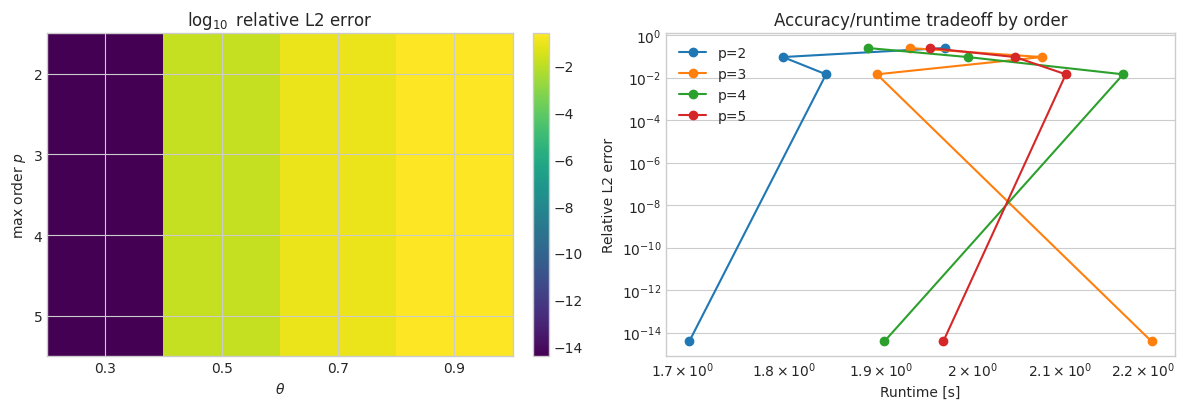

In [ ]:
pivot_err = accuracy_df.pivot(index="order", columns="theta", values="rel_l2_error")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

im = axes[0].imshow(jnp.log10(jnp.asarray(pivot_err.values)), aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(pivot_err.columns)))
axes[0].set_xticklabels([f"{x:.1f}" for x in pivot_err.columns])
axes[0].set_yticks(range(len(pivot_err.index)))
axes[0].set_yticklabels([str(x) for x in pivot_err.index])
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel(r"max order $p$")
axes[0].set_title(r"$\log_{10}$ relative L2 error")
fig.colorbar(im, ax=axes[0], fraction=0.045, pad=0.04)

for order in ACCURACY_ORDERS:
    sub = accuracy_df[accuracy_df["order"] == order]
    axes[1].plot(sub["runtime_s"], sub["rel_l2_error"], marker="o", label=f"p={order}")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Runtime [s]")
axes[1].set_ylabel("Relative L2 error")
axes[1].set_title("Accuracy/runtime tradeoff by order")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

## Story 3: Solver Comparison

Compare a small set of production-relevant solver profiles on a fixed dataset and fixed $p$.

,solver,runtime_s,runtime_std_s,rel_l2_error
0,balanced_fixed,1.832318,0.026635,0.068326
1,fast_fixed,1.900267,0.121635,0.178912
2,accurate_fixed,1.956814,0.123521,0.009356
3,adaptive_dehnen_paper,2.426794,0.128173,0.265075
4,balanced_dehnen_error,3.323021,0.047452,0.433394


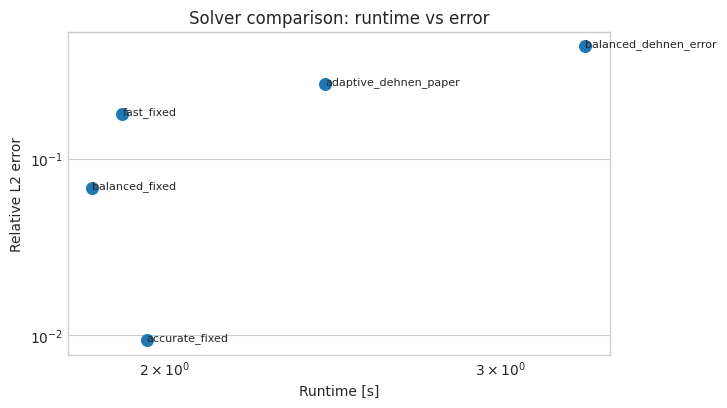

In [ ]:
compare_key = jax.random.PRNGKey(2)
cmp_positions, cmp_masses, _ = bench_utils.generate_random_distribution(
    COMPARE_N,
    key=compare_key,
    dtype=jnp.float64,
)
cmp_direct = direct_accelerations(cmp_positions, cmp_masses, softening=SOFTENING)

compare_specs = [
    dict(label="fast_fixed", kwargs=dict(preset=FMMPreset.FAST, theta=0.75)),
    dict(label="balanced_fixed", kwargs=dict(preset=FMMPreset.BALANCED, theta=0.60)),
    dict(label="accurate_fixed", kwargs=dict(preset=FMMPreset.ACCURATE, theta=0.45)),
    dict(
        label="balanced_dehnen_error",
        kwargs=dict(
            preset=FMMPreset.BALANCED,
            theta=0.60,
            advanced=replace(BASE_ADVANCED, mac_type="dehnen_error"),
        ),
    ),
    dict(
        label="adaptive_dehnen_paper",
        kwargs=dict(
            preset=FMMPreset.BALANCED,
            theta=0.60,
            adaptive_order=True,
            p_gears=(2, 3, 4),
            adaptive_error_model="dehnen_paper",
            adaptive_eps=1.0e-2,
        ),
    ),
]

compare_rows = []
for spec in compare_specs:
    scenario_kwargs = dict(ACCURACY_SOLVER_KWARGS)
    scenario_kwargs.update(spec["kwargs"])
    solver = FastMultipoleMethod(**scenario_kwargs)

    mean_s, std_s, estimate = timed_compute(
        solver,
        cmp_positions,
        cmp_masses,
        leaf_size=COMPARE_LEAF,
        max_order=COMPARE_ORDER,
        warmup=COMPARE_WARMUP,
        runs=COMPARE_RUNS,
    )
    compare_rows.append(
        {
            "solver": spec["label"],
            "runtime_s": mean_s,
            "runtime_std_s": std_s,
            "rel_l2_error": relative_l2_error(estimate, cmp_direct),
        }
    )

compare_df = pd.DataFrame(compare_rows).sort_values("runtime_s").reset_index(drop=True)
display(compare_df)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(compare_df["runtime_s"], compare_df["rel_l2_error"], s=70)
for _, row in compare_df.iterrows():
    ax.annotate(row["solver"], (row["runtime_s"], row["rel_l2_error"]), fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Runtime [s]")
ax.set_ylabel("Relative L2 error")
ax.set_title("Solver comparison: runtime vs error")
plt.show()

## Notes

- This notebook intentionally avoids low-level operator diagnostics and deep memory forensics.
- Keep this as the publication-style benchmark status notebook.
- Continue using dedicated notebooks for GPU memory internals and one-off debugging probes.